In [120]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Union
from pathlib import Path
import glob
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add current working directory to Python path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

print(f"Added to path: {current_dir}")

Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt


def plot_histograms_with_stats(
    dfs,
    metric,
    titles=None,
    bins='auto',
    density=False,
    x_range=(0, 1),
    ncols=2,
    figsize_per_row=(12, 5),
    shared_y=True,
    suptitle_name=None
):
    """
    Plot histograms with stats for a list of DataFrames.

    Parameters
    ----------
    dfs : list of pd.DataFrame
        List of DataFrames to plot.
    metric : str
        Column name to plot.
    titles : list of str, optional
        Titles for each histogram. If None, default titles are used.
    bins : int, sequence, or str
        Histogram bins passed to matplotlib.
    density : bool
        Whether to normalize histogram.
    x_range : tuple, optional
        Shared x-axis range for all histograms. If None, computed from all dfs.
    ncols : int
        Number of histograms per row. Default is 2.
    figsize_per_row : tuple
        Base figure size per row, default (12, 5).
    shared_y : bool
        If True, keep the same y-axis scale across all histograms.
    """

    if not dfs:
        print("No DataFrames provided.")
        return

    for i, df in enumerate(dfs):
        if metric not in df.columns:
            print(f"Incorrect metric name in df index {i}: '{metric}' not found.")
            return

    if titles is None:
        titles = [f"DF {i+1}" for i in range(len(dfs))]
    elif len(titles) != len(dfs):
        print("Length of titles must match length of dfs.")
        return

    values_list = [df[metric].dropna() for df in dfs]

    if all(len(values) == 0 for values in values_list):
        print("All DataFrames have only NaN values for this metric.")
        return

    n_plots = len(dfs)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_row[0], figsize_per_row[1] * nrows),
        squeeze=False
    )

    if suptitle_name is None:
        suptitle_name = metric
    fig.suptitle(suptitle_name, fontsize=14)

    range_min, range_max = x_range

    # ---- compute common y-axis max first ----
    common_y_max = None
    bin_edges_global = None

    if shared_y:
        non_empty_values = [np.asarray(v) for v in values_list if len(v) > 0]

        if len(non_empty_values) > 0:
            ref_values = non_empty_values[0]
            in_range_ref = ref_values[(ref_values >= range_min) & (ref_values <= range_max)]
            _, bin_edges_global = np.histogram(
                in_range_ref,
                bins=bins,
                range=(range_min, range_max)
            )

            bin_width = bin_edges_global[1] - bin_edges_global[0]
            y_max_candidates = []

            for values in non_empty_values:
                in_range  = values[(values >= range_min) & (values <= range_max)]
                underflow = values[values < range_min]
                overflow  = values[values > range_max]

                counts, _ = np.histogram(
                    in_range,
                    bins=bin_edges_global,
                    range=(range_min, range_max)
                )

                if density:
                    hist_heights      = counts / (len(values) * bin_width)
                    underflow_height  = len(underflow) / (len(values) * bin_width)
                    overflow_height   = len(overflow)  / (len(values) * bin_width)
                else:
                    hist_heights      = counts
                    underflow_height  = len(underflow)
                    overflow_height   = len(overflow)

                current_max = max(
                    np.max(hist_heights) if len(hist_heights) > 0 else 0,
                    underflow_height,
                    overflow_height,
                )
                y_max_candidates.append(current_max)

            common_y_max = max(y_max_candidates) * 1.08 if y_max_candidates else None
    # -----------------------------------------

    def _add_hist_with_stats(ax, values, title):
        values = np.asarray(values)

        in_range  = values[(values >= range_min) & (values <= range_max)]
        underflow = values[values < range_min]
        overflow  = values[values > range_max]

        if shared_y and bin_edges_global is not None:
            bin_edges = bin_edges_global
        else:
            _, bin_edges = np.histogram(
                in_range,
                bins=bins,
                range=(range_min, range_max)
            )

        bin_width = bin_edges[1] - bin_edges[0]

        # Main histogram (in-range values only)
        ax.hist(
            in_range,
            bins=bin_edges,
            density=False,          # we handle density manually below
            color="skyblue",
            edgecolor="black"
        )

        # Recompute heights for in-range so we can normalise consistently
        counts, _ = np.histogram(in_range, bins=bin_edges)
        if density and len(values) > 0:
            # Re-draw with correct density heights
            ax.cla()
            heights = counts / (len(values) * bin_width)
            ax.bar(
                bin_edges[:-1],
                heights,
                width=bin_width,
                align='edge',
                color="skyblue",
                edgecolor="black"
            )

        # ---- Left underflow bin ----
        underflow_x      = range_min - bin_width / 2
        underflow_count  = len(underflow)
        underflow_height = (underflow_count / (len(values) * bin_width)) if density else underflow_count

        ax.bar(
            underflow_x,
            underflow_height,
            width=bin_width * 0.95,
            color='skyblue',
            edgecolor='black',
            linewidth=0.8
        )

        # ---- Right overflow bin ----
        overflow_x      = range_max + bin_width / 2
        overflow_count  = len(overflow)
        overflow_height = (overflow_count / (len(values) * bin_width)) if density else overflow_count

        ax.bar(
            overflow_x,
            overflow_height,
            width=bin_width * 0.95,
            color='skyblue',
            edgecolor='black',
            linewidth=0.8
        )

        # Axis limits: make room for both overflow bars
        ax.set_xlim(range_min - bin_width * 1.55, range_max + bin_width * 1.55)

        if shared_y and common_y_max is not None:
            ax.set_ylim(0, common_y_max)

        # ---- Tick positions ----
        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins='auto', steps=[1, 2, 5, 10]))
        fig.canvas.draw()

        auto_ticks = [
            t for t in ax.get_xticks()
            if range_min <= t <= range_max
            and not np.isclose(t, range_min, atol=bin_width * 0.6)
            and not np.isclose(t, range_max, atol=bin_width * 0.6)
        ]
        tick_positions = [underflow_x] + auto_ticks + [overflow_x]
        tick_labels    = [f'<{range_min:g}'] + [f'{t:g}' for t in auto_ticks] + [f'≥{range_max:g}']

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right')

        ax.set_title(title)
        ax.set_xlabel("Value")
        ax.set_ylabel("Density" if density else "Frequency")

        median_v = np.median(values)
        ax.text(
            0.02,
            0.98,
            f"Median: {median_v:.4f}",
            transform=ax.transAxes,
            va="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
            fontsize=12,
        )

    for idx, (values, title) in enumerate(zip(values_list, titles)):
        row = idx // ncols
        col = idx % ncols
        ax = axes[row][col]

        if len(values) == 0:
            ax.set_title(title)
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_axis_off()
        else:
            _add_hist_with_stats(ax, values, title)

    for idx in range(n_plots, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row][col].set_axis_off()

    plt.tight_layout()
    plt.show()

In [ ]:
def _prepare_time_filtered_df(df, start_date=None, end_date=None):
    """Helper: ensure datetime and filter by dates."""
    df = df.copy()

    if not pd.api.types.is_datetime64_any_dtype(df["timestamp_utc"]):
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])

    if start_date is not None or end_date is not None:
        if isinstance(start_date, str):
            start_date = pd.to_datetime(start_date)
        if isinstance(end_date, str):
            end_date = pd.to_datetime(end_date)

        if start_date is not None:
            df = df[df["timestamp_utc"] >= start_date]
        if end_date is not None:
            df = df[df["timestamp_utc"] <= end_date]

    return df


def plot_water_meter_anomalies(
    df_actuals,
    df_predicted,
    df_red_dots,
    figsize=(14, 6),
    title="Water Meter: Actual vs Predicted Values",
    start_date=None,
    end_date=None,
):
    """
    df_actuals:  columns timestamp_utc, Diff
    df_predicted: columns timestamp_utc, predicted, residual, is_anomaly_predicted, is_anomaly_actual
    df_red_dots: columns timestamp_utc (candidate extra timestamps)
    """

    # --- 3-sigma band based on residuals ---
    if not df_predicted.empty and "residual" in df_predicted.columns:
        res_mean = df_predicted["residual"].mean()
        res_std = df_predicted["residual"].std(ddof=1)
        band = res_mean + 3 * res_std

        df_predicted = df_predicted.copy()
        df_predicted["upper_band"] = df_predicted["predicted"] + band
        df_predicted["lower_band"] = df_predicted["predicted"] - band
    # ---------------------------------------
    
    # Prepare and filter separately
    df_a = _prepare_time_filtered_df(df_actuals, start_date, end_date)
    df_p = _prepare_time_filtered_df(df_predicted, start_date, end_date)
    df_r = _prepare_time_filtered_df(df_red_dots, start_date, end_date)
    df_r_line = pd.DataFrame()

    # Keep only timestamps where Diff is NaN in df_a but not NaN in df_r
    if not df_a.empty and not df_r.empty:
        # Select only needed columns to avoid clashes
        tmp_a = df_a[["timestamp_utc", "Diff"]].rename(columns={"Diff": "Diff_a"})
        tmp_r = df_r[["timestamp_utc", "Diff"]].rename(columns={"Diff": "Diff_r"})
    
        merged = tmp_r.merge(tmp_a, on="timestamp_utc", how="left")
    
        # Condition: Diff_a is NaN (missing in actuals) AND Diff_r is not NaN
        mask = merged["Diff_a"].isna() & merged["Diff_r"].notna()
    
        # Keep only those timestamps in df_r
        df_r = df_r[df_r["timestamp_utc"].isin(merged.loc[mask, "timestamp_utc"])]
        
        df_r_line = df_r[df_r["timestamp_utc"] < df_a["timestamp_utc"].iloc[0]].copy()
        df_r = df_r[df_r["timestamp_utc"] >= df_a["timestamp_utc"].iloc[0]]


    # Update title if zoomed
    if start_date is not None and end_date is not None:
        if isinstance(start_date, str):
            start_date = pd.to_datetime(start_date)
        if isinstance(end_date, str):
            end_date = pd.to_datetime(end_date)
        date_range = (
            f" ({start_date.strftime('%Y-%m-%d %H:%M')} "
            f"to {end_date.strftime('%Y-%m-%d %H:%M')})"
        )
        title = title + date_range

    fig, ax = plt.subplots(figsize=figsize, dpi=100)

    # Actuals (Diff)
    ax.plot(
        df_a["timestamp_utc"],
        df_a["Diff"],
        color="#2E86AB",
        linewidth=2.5,
        marker="o",
        markersize=5,
        label="Actual (Diff)",
        zorder=3,
        alpha=0.9,
    )

    # Predicted
    ax.plot(
        df_p["timestamp_utc"],
        df_p["predicted"],
        color="#A23B72",
        linewidth=2,
        marker="s",
        markersize=4,
        label="Predicted",
        zorder=2,
        alpha=0.8,
        linestyle="--",
    )
    
    # 3-sigma upper/lower band
    if "upper_band" in df_p.columns and "lower_band" in df_p.columns:
        ax.plot(
            df_p["timestamp_utc"],
            df_p["upper_band"],
            color="gray",
            linestyle=":",
            linewidth=1.5,
            label="3σ upper band",
            zorder=1,
            alpha=0.8,
        )
        ax.plot(
            df_p["timestamp_utc"],
            df_p["lower_band"],
            color="gray",
            linestyle=":",
            linewidth=1.5,
            label="3σ lower band",
            zorder=1,
            alpha=0.8,
        )
        # Optional: shaded band
        #ax.fill_between(
        #    df_p["timestamp_utc"],
        #    df_p["lower_band"],
        #    df_p["upper_band"],
        #    color="gray",
        #    alpha=0.15,
        #    zorder=0,
        #)

    # Red dots only for timestamps not in df_actuals
    if not df_r.empty:
        ax.scatter(
            df_r["timestamp_utc"],
            df_r["Diff"],  # or np.nan if you want them detached from y-scale
            color="red",
            s=40,
            marker="o",
            label="Extra timestamps",
            zorder=5,
        )
    
    if not df_r_line.empty:    
        ax.plot(
            df_r_line["timestamp_utc"],
            df_r_line["Diff"],
            color="red",
            linewidth=2.5,
            marker="o",
            markersize=5,
            label="Training Data",
            zorder=3,
            alpha=0.8,
        )

    # Optional anomalies on actuals
    if "is_anomaly_predicted" in df_p.columns:
        anomalies = df_p[df_p["is_anomaly_predicted"] == 1]
        if len(anomalies) > 0:
            ax.scatter(
                anomalies["timestamp_utc"],
                anomalies["actual"],
                color="#F18F01",
                s=150,
                marker="X",
                label="Anomaly (Predicted)",
                zorder=4,
                edgecolors="#C41E3A",
                linewidth=2,
            )
            
    # Optional anomalies on actuals
    if "is_anomaly_actual" in df_p.columns:
        anomalies = df_p[df_p["is_anomaly_actual"] != 0]
        if len(anomalies) > 0:
            ax.scatter(
                anomalies["timestamp_utc"],
                anomalies["actual"],
                color="#FF03CD",
                s=150,
                marker="P",
                label="Anomaly (Actual)",
                zorder=4,
                edgecolors="#C41E3A",
                linewidth=2,
            )

    ax.set_xlabel("Timestamp (UTC)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Water Consumption (Diff)", fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=20)

    # Determine global time range from all non-empty dfs
    timestamps = []
    for d in (df_a, df_p, df_r):
        if not d.empty:
            timestamps.append(d["timestamp_utc"].min())
            timestamps.append(d["timestamp_utc"].max())

    if timestamps:
        t_min, t_max = min(timestamps), max(timestamps)
        time_range = (t_max - t_min).total_seconds()
    else:
        time_range = 0

    if time_range < 3600:
        date_format = "%H:%M:%S"
        date_locator = mdates.MinuteLocator(interval=10)
    elif time_range < 86400:
        date_format = "%H:%M"
        date_locator = mdates.HourLocator(interval=2)
    elif time_range < 604800:
        date_format = "%Y-%m-%d %H:%M"
        date_locator = mdates.AutoDateLocator()
    else:
        date_format = "%Y-%m-%d"
        date_locator = mdates.AutoDateLocator()

    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax.xaxis.set_major_locator(date_locator)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.legend(loc="best", fontsize=10, framealpha=0.95)
    ax.set_facecolor("#F8F9FA")
    fig.patch.set_facecolor("white")
    fig.tight_layout()

    return fig, ax


In [123]:
from pathlib import Path
from typing import List
import numpy as np
import pandas as pd
import pickle

# Extra columns for timing information
EXTRA_COLS = [
    "train_train_time_seconds",
    "second_train_time_seconds",
    "prediction_time_seconds",
    "number_of_anomalies",
    "number_of_anomalies_robust",
]

def load_model_results(csv_filepath: str, verbose: bool = True) -> pd.DataFrame:
    """
    Load and filter model results from CSV file.

    Returns only successful runs.
    """
    try:
        df = pd.read_csv(csv_filepath)
        successful = df[df["status"] == "success"].copy()

        if verbose and len(successful) > 0:
            print(f"✓ Loaded {len(successful)} successful runs from {csv_filepath}")

        return successful
    except Exception as e:
        print(f"✗ Error loading {csv_filepath}: {e}")
        return pd.DataFrame()

def extract_metrics(
    df: pd.DataFrame,
    include_non_zero_only: bool = False,
    unresampled: bool = False,
) -> pd.DataFrame:
    """
    Extract metric columns from results dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Results dataframe
    include_non_zero_only : bool
        If True, extract only _nz metrics and summary count metrics
    unresampled : bool
        If True, use unresampled_metric_* columns, otherwise metric_* columns
    """
    if unresampled:
        metric_cols = [col for col in df.columns if col.startswith("unresampled_metric_")]
        total_count_col = "unresampled_metric_total_count"
        non_zero_count_col = "unresampled_metric_non_zero_count"
        zero_count_col = "unresampled_metric_zero_count"
        non_zero_percentage_col = "unresampled_metric_non_zero_percentage"
    else:
        metric_cols = [col for col in df.columns if col.startswith("metric_")]
        total_count_col = "metric_total_count"
        non_zero_count_col = "metric_non_zero_count"
        zero_count_col = "metric_zero_count"
        non_zero_percentage_col = "metric_non_zero_percentage"

    if include_non_zero_only:
        metric_cols = [
            col
            for col in metric_cols
            if col.endswith("_nz")
            or col in [
                total_count_col,
                non_zero_count_col,
                zero_count_col,
                non_zero_percentage_col,
            ]
        ]

    return df[metric_cols]

def compute_metrics_summary(
    csv_filepaths: List[str],
    model_names: List[str] = None,
    include_non_zero_only: bool = False,
    only_converged: bool = True,
    verbose: bool = True,
    unresampled: bool = False,
    exclude_high_mae: bool = False,   # <-- new flag
    mae_threshold: float = 50.0,      # <-- optional parameter
) -> pd.DataFrame:
    """
    Compute mean, std and median of metrics across samples for each model.

    Important:
    Only considers filenames that are successful and converged in all models.
    Metric type is controlled by the unresampled flag.
    Optionally excludes files where (un)resampled_metric_mae > mae_threshold.
    """
    if not csv_filepaths:
        raise ValueError("No CSV files found")

    if model_names is None:
        model_names = [Path(f).stem for f in csv_filepaths]

    if len(csv_filepaths) != len(model_names):
        raise ValueError(
            f"Mismatch: {len(csv_filepaths)} files vs {len(model_names)} names"
        )

    model_data_metrics = {}
    model_data_full = {}
    all_metrics = set()
    successful_counts = {}
    per_model_filenames = {}
    per_model_filenames_all = {}

    if verbose:
        print(f"Loading {len(csv_filepaths)} model(s)...")
        print("-" * 80)

    # choose which MAE column to use
    mae_col = "unresampled_metric_mae" if unresampled else "metric_mae"

    for filepath, model_name in zip(csv_filepaths, model_names):
        df = load_model_results(filepath, verbose=verbose)
        
        per_model_filenames_all[model_name] = set(df["filename"].dropna().unique())

        if only_converged:
            if "converged_train" not in df.columns or "converged_second" not in df.columns:
                raise ValueError(
                    f"Columns 'converged_train' and/or 'converged_second' not found in {filepath}"
                )
            df = df[
                (df["converged_train"] == True) &
                (df["converged_second"] == True)
            ].copy()

            if verbose:
                print(f"  {model_name}: filtered to {len(df)} converged runs")

        if "filename" not in df.columns:
            raise ValueError(f"'filename' column not found in {filepath}")

        # ---- NEW FILTER HERE ----
        if exclude_high_mae:
            if mae_col not in df.columns:
                raise ValueError(f"Column '{mae_col}' not found in {filepath}")
            before = len(df)
            df = df[df[mae_col] <= mae_threshold].copy()
            if verbose:
                removed = before - len(df)
                print(
                    f"  {model_name}: excluded {removed} rows with {mae_col} > {mae_threshold}"
                )
        # -------------------------

        per_model_filenames[model_name] = set(df["filename"].dropna().unique())
        model_data_full[model_name] = df

    if not per_model_filenames:
        raise ValueError("No models loaded")

    common_filenames = set.intersection(*per_model_filenames.values())
    
    #with open('./pickles/common_filenames.pkl', 'wb') as f:
    #    pickle.dump(common_filenames, f)
    
    common_filenames_all = set.intersection(*per_model_filenames_all.values())
    
    with open('./pickles/common_filenames_all.pkl', 'wb') as f:
        pickle.dump(common_filenames_all, f)

    if verbose:
        print("-" * 80)
        print(
            f"Common filenames across all models (successful + converged"
            f"{' + MAE filtered' if exclude_high_mae else ''}): {len(common_filenames)}"
        )

    # --- rest of your original function stays the same ---
    for model_name in model_names:
        df = model_data_full[model_name]
        df = df[df["filename"].isin(common_filenames)].copy()

        if len(df) > 0:
            metrics_df = extract_metrics(
                df,
                include_non_zero_only=include_non_zero_only,
                unresampled=unresampled,
            )
            model_data_metrics[model_name] = metrics_df
            model_data_full[model_name] = df
            successful_counts[model_name] = len(metrics_df)
            all_metrics.update(metrics_df.columns)

            if verbose:
                print(f"  {model_name}: {len(metrics_df)} rows after filename intersection")
        else:
            model_data_metrics[model_name] = None
            model_data_full[model_name] = None
            successful_counts[model_name] = 0

            if verbose:
                print(f"  {model_name}: 0 rows after filename intersection")

    if verbose:
        print("-" * 80)

    all_metrics = sorted(all_metrics)
    summary_rows = []

    for metric in all_metrics:
        row_data = {"Metric": metric}

        for model_name in model_names:
            if model_data_metrics[model_name] is None:
                row_data[f"{model_name}_Mean"] = np.nan
                row_data[f"{model_name}_Std"] = np.nan
                row_data[f"{model_name}_Median"] = np.nan
            else:
                metrics_df = model_data_metrics[model_name]
                if metric in metrics_df.columns:
                    series = metrics_df[metric]
                    row_data[f"{model_name}_Mean"] = series.mean()
                    row_data[f"{model_name}_Std"] = series.std()
                    row_data[f"{model_name}_Median"] = series.median()
                else:
                    row_data[f"{model_name}_Mean"] = np.nan
                    row_data[f"{model_name}_Std"] = np.nan
                    row_data[f"{model_name}_Median"] = np.nan

        summary_rows.append(row_data)

    for time_col in EXTRA_COLS:
        row_data = {"Metric": time_col}

        for model_name in model_names:
            df_full = model_data_full.get(model_name)
            if df_full is None or time_col not in df_full.columns:
                row_data[f"{model_name}_Mean"] = np.nan
                row_data[f"{model_name}_Std"] = np.nan
                row_data[f"{model_name}_Median"] = np.nan
            else:
                series = df_full[time_col]
                row_data[f"{model_name}_Mean"] = series.mean()
                row_data[f"{model_name}_Std"] = series.std()
                row_data[f"{model_name}_Median"] = series.median()

        summary_rows.append(row_data)

    summary_df = pd.DataFrame(summary_rows)

    summary_df.attrs["model_names"] = model_names
    summary_df.attrs["successful_counts"] = successful_counts
    summary_df.attrs["include_non_zero_only"] = include_non_zero_only
    summary_df.attrs["only_converged"] = only_converged
    summary_df.attrs["unresampled"] = unresampled
    summary_df.attrs["common_filenames_count"] = len(common_filenames)

    return summary_df

def format_metrics_table(
    summary_df: pd.DataFrame,
    model_names: List[str] = None,
    decimal_places: int = 4,
    include_non_zero_only: bool = False,
) -> pd.DataFrame:
    """
    Format metrics summary table as 'mean ± std | median' for display.
    """
    if model_names is None:
        model_names = summary_df.attrs.get(
            "model_names",
            list(
                set(
                    [
                        col.replace("_Mean", "")
                        .replace("_Std", "")
                        .replace("_Median", "")
                        for col in summary_df.columns
                        if col != "Metric"
                    ]
                )
            ),
        )

    df_display = summary_df.copy()

    if include_non_zero_only:
        df_display = df_display[
            df_display["Metric"].str.contains(
                "_nz|total_count|non_zero_count|non_zero_percentage", na=False
            )
            | df_display["Metric"].isin(EXTRA_COLS)
        ].copy()

    formatted_rows = []

    for _, row in df_display.iterrows():
        formatted_row = {"Metric": row["Metric"]}

        for model_name in model_names:
            mean_col = f"{model_name}_Mean"
            std_col = f"{model_name}_Std"
            median_col = f"{model_name}_Median"

            mean_val = row.get(mean_col, np.nan)
            std_val = row.get(std_col, np.nan)
            median_val = row.get(median_col, np.nan)

            if pd.notna(mean_val) and pd.notna(std_val) and pd.notna(median_val):
                formatted_row[model_name] = (
                    f"{mean_val:.{decimal_places}f} ± "
                    f"{std_val:.{decimal_places}f} | "
                    f"{median_val:.{decimal_places}f}"
                )
            else:
                formatted_row[model_name] = "N/A"

        formatted_rows.append(formatted_row)

    return pd.DataFrame(formatted_rows)

def display_metrics(
    summary_df: pd.DataFrame,
    model_names: List[str] = None,
    show_all: bool = False,
    decimal_places: int = 4,
) -> pd.DataFrame:
    """
    Display metrics summary as a nice pandas table in Jupyter.
    """
    if model_names is None:
        model_names = summary_df.attrs.get(
            "model_names",
            list(
                set(
                    [
                        col.replace("_Mean", "").replace("_Std", "")
                        for col in summary_df.columns
                        if col != "Metric"
                    ]
                )
            ),
        )

    formatted = format_metrics_table(
        summary_df,
        model_names,
        decimal_places,
        include_non_zero_only=not show_all,
    )

    metric_mode = "unresampled" if summary_df.attrs.get("unresampled", False) else "regular"

    print(f"Metrics Summary - {'Non-Zero Metrics' if not show_all else 'All Metrics'}")
    print(f"Metric type: {metric_mode}")
    print(f"Models: {', '.join(model_names)}")

    if "common_filenames_count" in summary_df.attrs:
        print(f"Common filenames in all models: {summary_df.attrs['common_filenames_count']}")

    if "successful_counts" in summary_df.attrs:
        counts = summary_df.attrs["successful_counts"]
        for m in model_names:
            print(f"  {m}: {counts[m]} rows after common filename filtering")

    print()

    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    pd.set_option("display.max_colwidth", None)

    return formatted

def get_metric_comparison(
    summary_df: pd.DataFrame,
    metric_name: str,
    model_names: List[str] = None,
) -> pd.DataFrame:
    """
    Extract comparison for a specific metric across models.
    """
    if model_names is None:
        model_names = summary_df.attrs.get(
            "model_names",
            list(
                set(
                    [
                        col.replace("_Mean", "").replace("_Std", "")
                        for col in summary_df.columns
                        if col != "Metric"
                    ]
                )
            ),
        )

    metric_row = summary_df[summary_df["Metric"] == metric_name]

    if len(metric_row) == 0:
        print(f"✗ Metric '{metric_name}' not found")
        print("\nAvailable metrics:")
        for i, m in enumerate(sorted(summary_df["Metric"].unique()), 1):
            print(f"  {i:2}. {m}")
        return None

    comparison = [{"Metric": metric_name}]

    for model_name in model_names:
        mean_val = metric_row[f"{model_name}_Mean"].values[0]
        std_val = metric_row[f"{model_name}_Std"].values[0]

        if pd.notna(mean_val):
            comparison[0][model_name] = f"{mean_val:.6f} ± {std_val:.6f}"
        else:
            comparison[0][model_name] = "N/A"

    return pd.DataFrame(comparison)

def list_available_metrics(summary_df: pd.DataFrame) -> None:
    """
    Display list of available metrics.
    """
    metrics = sorted(summary_df["Metric"].unique())

    print(f"Available metrics ({len(metrics)} total):\n")

    for i, m in enumerate(metrics, 1):
        print(f"  {i:2}. {m}")

## Metrics table comparison

In [124]:
csv_files = ['./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_all.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_all.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_all.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_weekly_fourier_all.csv',
             './gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_train_all.csv']

model_names = ['Local Level Only', 'Daily Seasonal', "Daily + Weekly Fourier", "Daily Steps + Weekly Fourier", "GRU"]

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names=model_names, unresampled=True, only_converged=True, exclude_high_mae=False)
table = display_metrics(summary, show_all=True)
display(table)

Loading 5 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_all.csv
  Local Level Only: filtered to 15227 converged runs
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_all.csv
  Daily Seasonal: filtered to 13607 converged runs
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_all.csv
  Daily + Weekly Fourier: filtered to 11531 converged runs
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_weekly_fourier_all.csv
  Daily Steps + Weekly Fourier: filtered to 12601 converged runs
✓ Loaded 19429 successful r

,Metric,Local Level Only,Daily Seasonal,Daily + Weekly Fourier,Daily Steps + Weekly Fourier,GRU
0,unresampled_metric_direction_accuracy,0.5354 ± 0.1403 | 0.5097,0.5910 ± 0.0920 | 0.5876,0.5910 ± 0.0915 | 0.5933,0.5914 ± 0.0897 | 0.5894,0.4941 ± 0.0930 | 0.4908
1,unresampled_metric_direction_accuracy_nz,0.4796 ± 0.1102 | 0.4783,0.5680 ± 0.0998 | 0.5671,0.5719 ± 0.1077 | 0.5752,0.5690 ± 0.0994 | 0.5686,0.4734 ± 0.0948 | 0.4724
2,unresampled_metric_mae,0.1948 ± 1.3981 | 0.0631,43958.3300 ± 3816083.9724 | 0.0608,5222.6385 ± 453411.1882 | 0.0542,67981.3073 ± 5901808.6354 | 0.0613,3258.6894 ± 282134.9322 | 0.0616
3,unresampled_metric_mae_nz,0.2389 ± 1.6446 | 0.0705,66062.6743 ± 5686360.3642 | 0.0679,6390.0734 ± 550009.9042 | 0.0597,99340.4597 ± 8550763.7706 | 0.0683,3649.4097 ± 314132.3703 | 0.0698
4,unresampled_metric_mape,66998775640921.9766 ± 1197733133760153.5000 | 3372429934452.3862,77370289756861235200.0000 ± 6715461586310071844864.0000 | 2795161234607.3765,11855009287287175168.0000 ± 1029214636761845596160.0000 | 2420944402017.3496,124810318291734478848.0000 ± 10834324197687911514112.0000 | 2918280033793.3408,9271105380856696832.0000 ± 804286325067560386560.0000 | 3338350343497.3325
5,unresampled_metric_mape_nz,1.3992 ± 7.0764 | 0.8012,28047120.2683 ± 2414171130.6053 | 0.7947,2115948.3102 ± 182131283.9938 | 0.6859,31757366.8043 ± 2733532632.0285 | 0.8007,1770561.3241 ± 152422429.2372 | 0.8094
6,unresampled_metric_max_residual,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,32233.9981 ± 2568910.8560 | 0.4325
7,unresampled_metric_max_residual_nz,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,29965.7635 ± 2579457.0304 | 0.4395
8,unresampled_metric_mean_residual,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,3258.6894 ± 282134.9322 | 0.0616
9,unresampled_metric_mean_residual_nz,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,3649.4097 ± 314132.3703 | 0.0698


In [125]:
csv_files = ['./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_all.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_all.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_all.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_weekly_fourier_all.csv',
             './gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_train_all.csv']

model_names = ['Local Level Only', 'Daily Seasonal', "Daily + Weekly Fourier", "Daily Steps + Weekly Fourier", "GRU"]

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names=model_names, unresampled=True, only_converged=False, exclude_high_mae=False)
table = display_metrics(summary, show_all=True)
display(table)

Loading 5 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_all.csv
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_all.csv
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_all.csv
✓ Loaded 19629 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_weekly_fourier_all.csv
✓ Loaded 19429 successful runs from ./gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_train_all.csv
--------------------------------------------------------------------------------
Common filenames across all models (successful

,Metric,Local Level Only,Daily Seasonal,Daily + Weekly Fourier,Daily Steps + Weekly Fourier,GRU
0,unresampled_metric_direction_accuracy,0.6127 ± 0.1923 | 0.5641,0.6223 ± 0.1347 | 0.5962,0.6215 ± 0.1319 | 0.6012,0.6228 ± 0.1316 | 0.5987,0.5241 ± 0.1121 | 0.5120
1,unresampled_metric_direction_accuracy_nz,0.4664 ± 0.1203 | 0.4615,0.5574 ± 0.1094 | 0.5563,0.5542 ± 0.1155 | 0.5524,0.5581 ± 0.1086 | 0.5571,0.4699 ± 0.1027 | 0.4655
2,unresampled_metric_mae,309454312.7884 ± 43103101892.0584 | 0.0231,241581966.7236 ± 33646907993.7182 | 0.0228,289152603.3577 ± 40274349232.2038 | 0.0215,260036526.2100 ± 36216113024.0010 | 0.0229,4269723146.9238 ± 572517325041.7640 | 0.0229
3,unresampled_metric_mae_nz,1243667973.0766 ± 163621524439.8056 | 0.0365,1169271630.7346 ± 153829931170.4886 | 0.0365,1229394838.5502 ± 161743331887.8671 | 0.0334,1194919232.3372 ± 157202360203.1786 | 0.0365,931508448.1002 ± 122570165257.7288 | 0.0373
4,unresampled_metric_mape,329774185238183259668480.0000 ± 45933384289880284615147520.0000 | 4226732832801.6782,87723271526542875820032.0000 ± 12214343385652814707425280.0000 | 4084717700979.9141,250551028427759042953216.0000 ± 34894821839717497120489472.0000 | 3772536460998.9521,148883815723353403031552.0000 ± 20730734815846164712128512.0000 | 4177323720342.8745,18496826874489255590100992.0000 ± 2576375760263407431785119744.0000 | 3822763978334.3818
5,unresampled_metric_mape_nz,22258965682.9612 ± 2928470993330.1260 | 0.8166,7287564247.8727 ± 957192573941.6385 | 0.8294,13580967702.5641 ± 1786640714155.4604 | 0.7563,9539232221.8392 ± 1253226326909.8354 | 0.8353,758552.3780 ± 99721484.6817 | 0.8965
6,unresampled_metric_max_residual,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,90974363467.9848 ± 9870198343174.4414 | 0.1827
7,unresampled_metric_max_residual_nz,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,74520563190.0319 ± 9805613221460.8848 | 0.2283
8,unresampled_metric_mean_residual,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,4269723146.9238 ± 572517325041.7640 | 0.0229
9,unresampled_metric_mean_residual_nz,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,931508448.1002 ± 122570165257.7288 | 0.0373


## TEST set


In [126]:
csv_files = ['./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_test.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_test.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_test.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_weekly_fourier_test.csv',
             './gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_test.csv']

model_names = ['Local Level Only', 'Daily Seasonal', "Daily + Weekly Fourier", "Daily Steps + Weekly Fourier", "GRU"]

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names=model_names, unresampled=True, only_converged=False, exclude_high_mae=False)
table = display_metrics(summary, show_all=True)
display(table)

Loading 5 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 4871 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_test.csv
✓ Loaded 4871 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_test.csv
✓ Loaded 4871 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_test.csv
✓ Loaded 4871 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_weekly_fourier_test.csv
✓ Loaded 4818 successful runs from ./gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_test.csv
--------------------------------------------------------------------------------
Common filenames across all models (successful

,Metric,Local Level Only,Daily Seasonal,Daily + Weekly Fourier,Daily Steps + Weekly Fourier,GRU
0,unresampled_metric_direction_accuracy,0.6105 ± 0.1931 | 0.5617,0.6213 ± 0.1347 | 0.5955,0.6198 ± 0.1311 | 0.5987,0.6214 ± 0.1312 | 0.5988,0.5218 ± 0.1063 | 0.5064
1,unresampled_metric_direction_accuracy_nz,0.4636 ± 0.1207 | 0.4591,0.5552 ± 0.1082 | 0.5556,0.5530 ± 0.1131 | 0.5515,0.5547 ± 0.1076 | 0.5556,0.4735 ± 0.1122 | 0.4653
2,unresampled_metric_mae,0.1010 ± 0.6550 | 0.0234,0.5155 ± 28.9763 | 0.0234,0.2941 ± 14.2589 | 0.0221,0.5486 ± 31.2096 | 0.0234,0.1936 ± 1.3471 | 0.0333
3,unresampled_metric_mae_nz,0.1314 ± 0.7525 | 0.0363,0.1270 ± 0.7358 | 0.0360,0.1167 ± 0.7159 | 0.0333,0.1286 ± 0.7415 | 0.0361,0.2355 ± 1.4713 | 0.0464
4,unresampled_metric_mape,32899291670974.8711 ± 512004403333073.7500 | 4131542264270.4751,1913859558693810.5000 ± 130473681496066672.0000 | 4108541812280.8706,956610080253669.5000 ± 64164200798245072.0000 | 3705567009148.8071,2057791891548534.2500 ± 140534125199249968.0000 | 4187416008962.7607,26268102562204.5234 ± 331228594795758.6875 | 3731320443411.5044
5,unresampled_metric_mape_nz,1.2700 ± 5.4721 | 0.8061,1.2994 ± 5.1026 | 0.8298,1.2131 ± 5.0845 | 0.7645,1.3364 ± 5.4050 | 0.8367,1.3218 ± 5.4485 | 0.9191
6,unresampled_metric_max_residual,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,2.2218 ± 18.1936 | 0.3923
7,unresampled_metric_max_residual_nz,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,2.2656 ± 18.3712 | 0.4140
8,unresampled_metric_mean_residual,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.1936 ± 1.3471 | 0.0333
9,unresampled_metric_mean_residual_nz,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.2355 ± 1.4713 | 0.0464


In [127]:
csv_files = ['./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_test.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_test.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_test.csv',
             './dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_weekly_fourier_test.csv',
             './gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_test.csv']

model_names = ['Local Level Only', 'Daily Seasonal', "Daily + Weekly Fourier", "Daily Steps + Weekly Fourier", "GRU"]

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names=model_names, unresampled=True, only_converged=True, exclude_high_mae=False)
table = display_metrics(summary, show_all=True)
display(table)

Loading 5 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 4871 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_test.csv
  Local Level Only: filtered to 3778 converged runs
✓ Loaded 4871 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_test.csv
  Daily Seasonal: filtered to 3370 converged runs
✓ Loaded 4871 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_test.csv
  Daily + Weekly Fourier: filtered to 2905 converged runs
✓ Loaded 4871 successful runs from ./dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_weekly_fourier_test.csv
  Daily Steps + Weekly Fourier: filtered to 3152 converged runs
✓ Loaded 4818 successful 

,Metric,Local Level Only,Daily Seasonal,Daily + Weekly Fourier,Daily Steps + Weekly Fourier,GRU
0,unresampled_metric_direction_accuracy,0.5347 ± 0.1415 | 0.5108,0.5918 ± 0.0956 | 0.5879,0.5903 ± 0.0938 | 0.5879,0.5923 ± 0.0938 | 0.5894,0.4922 ± 0.0848 | 0.4848
1,unresampled_metric_direction_accuracy_nz,0.4806 ± 0.1127 | 0.4766,0.5681 ± 0.1009 | 0.5686,0.5712 ± 0.1055 | 0.5714,0.5683 ± 0.1010 | 0.5686,0.4715 ± 0.0862 | 0.4678
2,unresampled_metric_mae,0.1901 ± 1.0192 | 0.0640,0.1856 ± 0.9744 | 0.0629,0.1697 ± 0.9485 | 0.0539,0.1868 ± 0.9661 | 0.0632,0.3616 ± 2.0631 | 0.0931
3,unresampled_metric_mae_nz,0.2195 ± 1.1115 | 0.0719,0.2142 ± 1.0875 | 0.0705,0.1980 ± 1.0594 | 0.0613,0.2169 ± 1.0959 | 0.0711,0.4165 ± 2.2077 | 0.1045
4,unresampled_metric_mape,61340103801857.0391 ± 812665052139636.5000 | 2801049755547.2905,60750051191193.7031 ± 742551299818816.7500 | 2457925482183.7881,57207366391687.3984 ± 619403714630546.2500 | 2014269434972.6189,57940802797636.8906 ± 651147406811182.8750 | 2417036311145.4844,48269258875117.6641 ± 521141781435932.6875 | 2823672813521.6611
5,unresampled_metric_mape_nz,1.4904 ± 8.1081 | 0.7912,1.4819 ± 7.5087 | 0.7984,1.3751 ± 7.5226 | 0.6861,1.4258 ± 5.3599 | 0.8003,1.5306 ± 8.4393 | 0.8160
6,unresampled_metric_max_residual,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,3.7345 ± 19.8555 | 1.1324
7,unresampled_metric_max_residual_nz,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,3.7481 ± 19.8912 | 1.1380
8,unresampled_metric_mean_residual,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.3616 ± 2.0631 | 0.0931
9,unresampled_metric_mean_residual_nz,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.0000 ± 0.0000 | 0.0000,0.4165 ± 2.2077 | 0.1045


In [128]:
with open("./pickles/common_filenames.pkl", "rb") as f:
    common_filenames = pickle.load(f)
    
with open("./pickles/common_filenames_all.pkl", "rb") as f:
    common_filenames_all = pickle.load(f)
    
dfs_total = [pd.read_csv(f) for f in csv_files]

dfs = [df[df["filename"].isin(common_filenames)].copy() for df in dfs_total]
dfs_all = [df[df["filename"].isin(common_filenames_all)].copy() for df in dfs_total]


In [129]:
plot_histograms_with_stats(
    dfs=dfs,
    metric="unresampled_metric_mae",
    titles=model_names,
    x_range=(0, 1),
    suptitle_name='MAE'
)

All DataFrames have only NaN values for this metric.


In [130]:
plot_histograms_with_stats(
    dfs=dfs,
    metric="unresampled_metric_wape",
    titles=model_names,
    x_range=(0, 5),
    suptitle_name='WAPE'
)

All DataFrames have only NaN values for this metric.


In [131]:
plot_histograms_with_stats(
    dfs=dfs,
    metric="unresampled_metric_normalized_rmse",
    titles=model_names,
    x_range=(0, 2),
    suptitle_name='nRMSE'
)

All DataFrames have only NaN values for this metric.


In [132]:
plot_histograms_with_stats(
    dfs=dfs,
    metric="unresampled_metric_prediction_bias",
    titles=model_names,
    x_range=(-0.04, 0.04),
    bins=100,
    suptitle_name='Bias'
)

All DataFrames have only NaN values for this metric.


In [133]:
import operator

def get_candidates(df, params):
    ops = {
        "==": operator.eq,
        "!=": operator.ne,
        "<": operator.lt,
        ">": operator.gt,
        "<=": operator.le,
        ">=": operator.ge,
    }

    mask = np.ones(len(df), dtype=bool)
    
    for p in params:
        col = p["name"]
        val = p["value"]
        comp = p["comparator"]
        
        if comp not in ops:
            raise ValueError(f"Unsupported comparator: {comp}")
        if col not in df.columns:
            raise ValueError(f"Column {col} not in dataframe")
        
        op = ops[comp]
        mask &= op(df[col], val)
        
    return df[mask]

In [134]:
df_candidates = get_candidates(
    dfs[3],
    params=[
        {"name": "converged_train", "value": True, "comparator": "=="},
        {"name": "converged_second", "value": True, "comparator": "=="},
        {"name": "status", "value": "success", "comparator": "=="},
        {"name": "unresampled_metric_mae_nz", "value": 100, "comparator": ">"},
    ]
)

In [135]:
display(df_candidates['filename'])

Series([], Name: filename, dtype: int64)

In [136]:
metric = 'unresampled_metric_normalized_rmse_nz'

for idx, df in enumerate(dfs):
    df_candidates = get_candidates(
    df,
    params=[
        {"name": "converged_train", "value": True, "comparator": "=="},
        {"name": "converged_second", "value": True, "comparator": "=="},
        {"name": "status", "value": "success", "comparator": "=="},
        {"name": metric, "value": 500, "comparator": ">"},
    ]
    )
    
    print(f"{idx} has these misbehaving files:\n {df_candidates['filename'].tolist()} with {df_candidates[metric].tolist()}.\n")


0 has these misbehaving files:
 [] with [].

1 has these misbehaving files:
 [] with [].

2 has these misbehaving files:
 [] with [].

3 has these misbehaving files:
 [] with [].

4 has these misbehaving files:
 [] with [].



In [137]:
 [112891, 113562, 108074]

[112891, 113562, 108074]

## Anomalies

In [138]:
ano_file = pd.read_csv('dynamic_trend_model/6_weeks_results_seasonal_uc_1_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_anomalies.csv')

In [139]:
ano_file['metric_pred_fp']

0    4
Name: metric_pred_fp, dtype: int64

In [140]:
import pandas as pd
import numpy as np
from pathlib import Path


def compute_metrics_summary_anomaly(
    csv_files: list[str],
    model_names: list[str] | None = None,
    only_converged: bool = True,
) -> pd.DataFrame:
    if model_names is None:
        model_names = [Path(p).stem for p in csv_files]
    assert len(model_names) == len(csv_files)

    # ------------------------------------------------------------------
    # 1. Load all DataFrames
    # ------------------------------------------------------------------
    dfs: dict[str, pd.DataFrame] = {}
    for name, path in zip(model_names, csv_files):
        df = pd.read_csv(path).set_index("filename")
        dfs[name] = df

    # ------------------------------------------------------------------
    # 2. Build common usable sensor set
    # ------------------------------------------------------------------
    if only_converged:
        usable_per_model = []
        for df in dfs.values():
            mask = (
                (df["status"] == "success")
                & (df["converged_train"] == True)
                & (df["converged_second"] == True)
            )
            usable_per_model.append(set(df.index[mask]))
        common_sensors = set.intersection(*usable_per_model)
    else:
        common_sensors = set.intersection(
            *[set(df.index[df["status"] == "success"]) for df in dfs.values()]
        )

    n_common = len(common_sensors)

    # ------------------------------------------------------------------
    # 3. Helper: compute metrics from aggregated confusion matrix counts
    # ------------------------------------------------------------------
    def scores_from_counts(tp, tn, fp, fn) -> dict:
        total = tp + tn + fp + fn
        accuracy  = (tp + tn) / total          if total > 0  else float("nan")
        precision = tp / (tp + fp)             if (tp + fp) > 0 else float("nan")
        recall    = tp / (tp + fn)             if (tp + fn) > 0 else float("nan")
        if pd.notna(precision) and pd.notna(recall) and (precision + recall) > 0:
            f1 = 2 * precision * recall / (precision + recall)
        else:
            f1 = float("nan")
        return {
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
        }

    # ------------------------------------------------------------------
    # 4. Sum confusion matrix counts over common sensors, compute scores
    # ------------------------------------------------------------------
    rows = []
    for name, df in dfs.items():
        subset = df.loc[df.index.isin(common_sensors)]
        row = {"Model": name, "N sensors": n_common}

        # Standard
        tp = subset["metric_pred_tp"].sum()
        tn = subset["metric_pred_tn"].sum()
        fp = subset["metric_pred_fp"].sum()
        fn = subset["metric_pred_fn"].sum()
        for label, val in scores_from_counts(tp, tn, fp, fn).items():
            row[label] = val

        # Robust
        tp_r = subset["metric_robust_pred_tp"].sum()
        tn_r = subset["metric_robust_pred_tn"].sum()
        fp_r = subset["metric_robust_pred_fp"].sum()
        fn_r = subset["metric_robust_pred_fn"].sum()
        for label, val in scores_from_counts(tp_r, tn_r, fp_r, fn_r).items():
            row[f"Robust {label}"] = val

        rows.append(row)

    return pd.DataFrame(rows).set_index("Model")

In [195]:
def plot_confusion_matrices(
    csv_files: list[str],
    model_names: list[str] | None = None,
    only_converged: bool = True,
) -> None:
    """
    Reads model result CSVs and renders confusion matrices for all models,
    for both z-score (standard) and MAD-score (robust) detection methods.
    Rows are actual values and column predicted one
    """
    from pathlib import Path
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    if model_names is None:
        model_names = [Path(p).stem for p in csv_files]
    assert len(model_names) == len(csv_files)

    # ── 1. Load all DataFrames ─────────────────────────────────────────────
    dfs: dict[str, pd.DataFrame] = {}
    for name, path in zip(model_names, csv_files):
        df = pd.read_csv(path).set_index("filename")
        dfs[name] = df

    # ── 2. Build common sensor set ─────────────────────────────────────────
    if only_converged:
        usable_per_model = []
        for df in dfs.values():
            mask = (
                (df["status"] == "success")
                & (df["converged_train"] == True)
                & (df["converged_second"] == True)
            )
            usable_per_model.append(set(df.index[mask]))
        common_sensors = set.intersection(*usable_per_model)
    else:
        common_sensors = set.intersection(
            *[set(df.index[df["status"] == "success"]) for df in dfs.values()]
        )

    # ── 3. Aggregate confusion matrix counts per model ─────────────────────
    scoring_configs = [
        ("Z-score",    "metric_pred_tp",        "metric_pred_tn",        "metric_pred_fp",        "metric_pred_fn"),
        ("MAD score",  "metric_robust_pred_tp",  "metric_robust_pred_tn", "metric_robust_pred_fp", "metric_robust_pred_fn"),
    ]

    n_models  = len(model_names)
    n_methods = len(scoring_configs)

    fig, axes = plt.subplots(
        n_models, n_methods,
        figsize=(4.5 * n_methods, 3.8 * n_models),
        squeeze=False,
    )
    fig.suptitle("Confusion matrices", fontsize=14, fontweight="bold", y=1.01)

    cmap_normal = plt.cm.Blues
    cmap_robust = plt.cm.Oranges

    for row_idx, (name, df) in enumerate(dfs.items()):
        subset = df.loc[df.index.isin(common_sensors)]

        for col_idx, (method_label, tp_col, tn_col, fp_col, fn_col) in enumerate(scoring_configs):
            ax = axes[row_idx][col_idx]
            cmap = cmap_normal if col_idx == 0 else cmap_robust

            tp = int(subset[tp_col].sum())
            tn = int(subset[tn_col].sum())
            fp = int(subset[fp_col].sum())
            fn = int(subset[fn_col].sum())

            # Matrix layout: rows = actual (Anomaly / Normal), cols = predicted (Anomaly / Normal)
            cm = np.array([[tp, fn],   # actual Anomaly  → [TP, FN]
                           [fp, tn]])  # actual Normal   → [FP, TN]

            im = ax.imshow(cm, cmap=cmap, aspect="auto")

            # Cell annotations
            total = cm.sum()
            thresh = cm.max() / 2.0
            for i in range(2):
                for j in range(2):
                    count = cm[i, j]
                    pct   = 100.0 * count / total if total > 0 else 0.0
                    color = "white" if count > thresh else "black"
                    ax.text(
                        j, i,
                        f"{pct:.1f}%",
                        ha="center", va="center",
                        fontsize=9, color=color, fontweight="bold",
                    )

            # Corner labels (TP / FN / FP / TN)
            corner_labels = [["TP", "FN"], ["FP", "TN"]]
            for i in range(2):
                for j in range(2):
                    ax.text(
                        j + 0.45, i - 0.42,
                        corner_labels[i][j],
                        ha="right", va="top",
                        fontsize=7, color="gray",
                        fontstyle="italic",
                    )

            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(["Predicted\nanomalous", "Predicted\nnormal"], fontsize=8)
            ax.set_yticklabels(["Actual\nanomalous", "Actual\nnormal"], fontsize=8)
            ax.tick_params(length=0)

            # Derived metrics in title
            precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
            recall    = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
            f1 = (2 * precision * recall / (precision + recall)
                  if not (np.isnan(precision) or np.isnan(recall)) and (precision + recall) > 0
                  else float("nan"))

            ax.set_title(
                f"{name}  ·  {method_label}\n"
                f"P={precision:.3f}  R={recall:.3f}  F1={f1:.3f}",
                fontsize=9, pad=6,
            )

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → confusion_matrices.png  |  common sensors: {len(common_sensors):,}")

In [142]:
csv_files_anomaly = ['dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_anomalies_test.csv',
                     'dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_anomalies_test.csv', 
                     'dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_anomalies_test.csv',
                     'dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_steps_anomalies_test.csv',
                     'gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_anomalies_test.csv'
                     ]

model_names_anomaly = ["Local Level Only", "Daily Steps", "Daily + Weekly Fourier","Daily Steps + Weekly Fourier", "GRU"]

# 2. Compute summary statistics
summary = compute_metrics_summary_anomaly(csv_files_anomaly, model_names=model_names_anomaly, only_converged=True)
#table = display_metrics(summary, show_all=True)
display(summary)

,N sensors,Accuracy,Precision,Recall,F1,Robust Accuracy,Robust Precision,Robust Recall,Robust F1
Model,,,,,,,,,
Local Level Only,2196,0.956007,0.398365,0.935751,0.558827,0.882873,0.200844,0.984766,0.333642
Daily Steps,2196,0.985391,0.806802,0.669730,0.731904,0.936536,0.313366,0.949826,0.471255
Daily + Weekly Fourier,2196,0.974124,0.537470,0.939394,0.683741,0.931672,0.300952,0.978804,0.460358
Daily Steps + Weekly Fourier,2196,0.985391,0.806802,0.669730,0.731904,0.936536,0.313366,0.949826,0.471255
GRU,2196,0.981758,0.661868,0.914056,0.767783,0.919951,0.289888,0.983931,0.447835


In [221]:
def plot_confusion_matrices_clean(
    csv_files: list[str],
    model_names: list[str] | None = None,
    only_converged: bool = True,
    output_path: str = "confusion_matrices_clean.png",
) -> None:
    """
    Renders clean confusion matrices (z-score only) for all models.
    No heatmap — plain cells with percentage in centre and TP/FN/FP/TN
    label in the upper-right corner of each cell.

    Layout: one row per model, axis labels show Actual / Predicted classes,
    and P / R / F1 are shown below each matrix.
    """
    from pathlib import Path
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    if model_names is None:
        model_names = [Path(p).stem for p in csv_files]
    assert len(model_names) == len(csv_files)

    # ── 1. Load DataFrames ─────────────────────────────────────────────────
    dfs: dict[str, pd.DataFrame] = {}
    for name, path in zip(model_names, csv_files):
        df = pd.read_csv(path).set_index("filename")
        dfs[name] = df

    # ── 2. Common sensor set ───────────────────────────────────────────────
    if only_converged:
        usable_per_model = []
        for df in dfs.values():
            mask = (
                (df["status"] == "success")
                & (df["converged_train"] == True)
                & (df["converged_second"] == True)
            )
            usable_per_model.append(set(df.index[mask]))
        common_sensors = set.intersection(*usable_per_model)
    else:
        common_sensors = set.intersection(
            *[set(df.index[df["status"] == "success"]) for df in dfs.values()]
        )

    n_models = len(model_names)

    # ── 3. Draw one matrix per model ───────────────────────────────────────
    fig, axes = plt.subplots(
        1, n_models,
        figsize=(3.6 * n_models, 4.2),
        squeeze=False,
    )
    fig.suptitle("Confusion Matrices (Z-Score)", fontsize=14, fontweight="bold", y=1.02)

    row_labels = ["Actual\nanomalous", "Actual\nnormal"]
    col_labels = ["Predicted\nanomalous", "Predicted\nnormal"]
    corner_labels = [["TP", "FN"], ["FP", "TN"]]

    # Cell colours: diagonal = light green, off-diagonal = light red
    cell_colors = [
        ["#d4edda", "#f8d7da"],   # row 0: TP green, FN red
        ["#f8d7da", "#d4edda"],   # row 1: FP red, TN green
    ]
    text_colors = [
        ["#155724", "#721c24"],
        ["#721c24", "#155724"],
    ]

    for col_idx, (name, df) in enumerate(dfs.items()):
        ax = axes[0][col_idx]
        subset = df.loc[df.index.isin(common_sensors)]

        tp = int(subset["metric_pred_tp"].sum())
        tn = int(subset["metric_pred_tn"].sum())
        fp = int(subset["metric_pred_fp"].sum())
        fn = int(subset["metric_pred_fn"].sum())

        cm = np.array([[tp, fn],
                       [fp, tn]])
        total = cm.sum()

        ax.set_xlim(0, 2)
        ax.set_ylim(0, 2)
        ax.set_aspect("equal")
        ax.axis("off")

        # ── Draw cells ────────────────────────────────────────────────────
        for i in range(2):
            for j in range(2):
                count = cm[i, j]
                pct   = 100.0 * count / total if total > 0 else 0.0

                # Cell rectangle (row 0 = top, so y = 1 - i)
                rect = mpatches.FancyBboxPatch(
                    (j + 0.04, 1 - i + 0.04),
                    0.92, 0.92,
                    boxstyle="round,pad=0.02",
                    linewidth=1.2,
                    edgecolor="#aaaaaa",
                    facecolor=cell_colors[i][j],
                )
                ax.add_patch(rect)

                # Percentage — centre of cell
                ax.text(
                    j + 0.5, 1 - i + 0.5,
                    f"{pct:.1f}%",
                    ha="center", va="center",
                    fontsize=13, fontweight="bold",
                    color=text_colors[i][j],
                )

                # TP/FN/FP/TN label — upper-right corner
                ax.text(
                    j + 0.93, 1 - i + 0.93,
                    corner_labels[i][j],
                    ha="right", va="top",
                    fontsize=12, color="#555555",
                    fontstyle="italic",
                )

        # ── Row labels (left side) ─────────────────────────────────────────
        for i, label in enumerate(row_labels):
            ax.text(
                -0.06, 1 - i + 0.5,
                label,
                ha="right", va="center",
                fontsize=12, color="#333333",
            )

        # ── Column labels (top) ────────────────────────────────────────────
        for j, label in enumerate(col_labels):
            ax.text(
                j + 0.5, 2.06,  # was 2.08
                label,
                ha="center", va="bottom",
                fontsize=12, color="#333333",
            )

        # ── Grid lines between cells ───────────────────────────────────────
        for v in [1]:
            ax.plot([0, 2], [v, v], color="#aaaaaa", lw=0.8)
            ax.plot([v, v], [0, 2], color="#aaaaaa", lw=0.8)

        # ── Metrics below matrix ───────────────────────────────────────────
        precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
        recall    = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
        f1 = (2 * precision * recall / (precision + recall)
              if not (np.isnan(precision) or np.isnan(recall)) and (precision + recall) > 0
              else float("nan"))

        ax.text(
            1.0, -0.18,
            f"P = {precision:.3f} | R = {recall:.3f} | F1 = {f1:.3f}",
            ha="center", va="top",
            fontsize=10, color="#333333",
        )

        # ── Model name as subplot title ────────────────────────────────────
        ax.set_title(name, fontsize=13, fontweight="bold", pad=50)  # was pad=18

    fig.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {output_path}  |  common sensors: {len(common_sensors):,}")

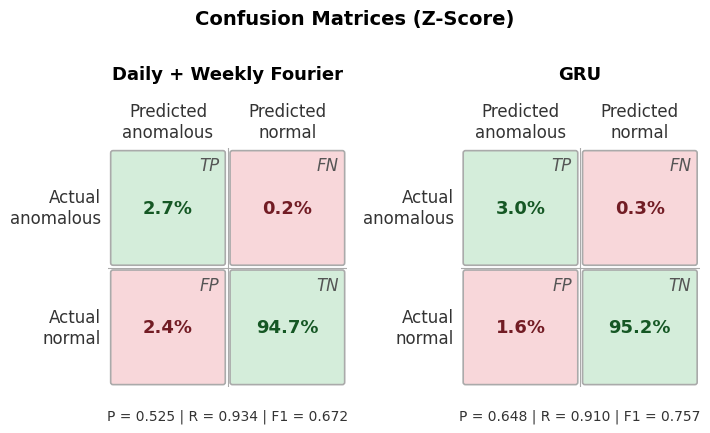

Saved → template/images/confusion_matrices_clean.png  |  common sensors: 2,893


In [222]:
plot_confusion_matrices_clean(
    csv_files=['dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_anomalies_test.csv',
                     'gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_anomalies_test.csv'
        ],
    model_names=["Daily + Weekly Fourier","GRU"],
    only_converged=True,
    output_path="template/images/confusion_matrices_clean.png"
)

In [223]:
def plot_zscore_distributions(
    zscore_csv_files: list[str],
    model_names: list[str] | None = None,
    result_csv_files: list[str] | None = None,
    only_converged: bool = True,
    clip: float = 5,
    output_path: str = "zscore_distributions.png",
) -> None:
    """
    Plot z-score distributions on clean prediction steps across models.

    Parameters:
    -----------
    zscore_csv_files : list[str]
        Paths to _zscores.csv files, one per model.
    model_names : list[str] | None
        Display names for each model. Defaults to CSV file stems.
    result_csv_files : list[str] | None
        Paths to the main result CSVs, used to filter to the common
        converged sensor set. If None, all sensors in the CSV are used.
    only_converged : bool
        If True, restricts to sensors that converged in all models.
        Only used when result_csv_files is provided.
    clip : float
        Clip z-scores to [-clip, clip] for plotting (default: 10.0).
    output_path : str
        Path to save the figure.
    """
    from pathlib import Path
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy import stats

    if model_names is None:
        model_names = [Path(p).stem.replace("_zscores", "") for p in zscore_csv_files]
    assert len(model_names) == len(zscore_csv_files)

    # ── 1. Build common sensor set from result CSVs (optional) ────────────
    common_sensors = None
    if result_csv_files is not None:
        assert len(result_csv_files) == len(zscore_csv_files)
        usable_per_model = []
        for path in result_csv_files:
            df = pd.read_csv(path).set_index("filename")
            if only_converged:
                mask = (
                    (df["status"] == "success")
                    & (df["converged_train"] == True)
                    & (df["converged_second"] == True)
                )
            else:
                mask = df["status"] == "success"
            usable_per_model.append(set(df.index[mask]))
        common_sensors = set.intersection(*usable_per_model)
        print(f"Common sensors: {len(common_sensors):,}")

    # ── 2. Load z-scores, filter to common sensors ─────────────────────────
    model_zscores: dict[str, np.ndarray] = {}
    for name, path in zip(model_names, zscore_csv_files):
        df = pd.read_csv(path)
        if common_sensors is not None:
            df = df[df["filename"].astype(str).isin({str(s) for s in common_sensors})]
        zs = df["z_score"].dropna()
        zs = zs[np.abs(zs) <= clip].values
        model_zscores[name] = zs
        print(f"  {name}: {len(zs):,} clean-step z-scores loaded")

    # ── 3. Plot ────────────────────────────────────────────────────────────
    colors = ["#185FA5", "#D85A30", "#1D9E75", "#7F77DD", "#BA7517"]
    xgrid  = np.linspace(-clip, clip, 600)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle("Z-Score Distribution on Prediction Values", fontsize=13, fontweight="bold")

    ax_kde, ax_bar = axes

    # ── KDE + N(0,1) reference ────────────────────────────────────────────
    for (name, zs), color in zip(model_zscores.items(), colors):
        kde = stats.gaussian_kde(zs)
        ax_kde.plot(xgrid, kde(xgrid), color=color, lw=2, label=name)
        ax_kde.fill_between(xgrid, kde(xgrid), alpha=0.08, color=color)

    ax_kde.plot(xgrid, stats.norm.pdf(xgrid), "k--", lw=1.2,
                alpha=0.6, label="N(0,1) ideal")

    for xv in [-3, 3]:
        ax_kde.axvline(xv, color="#E24B4A", lw=1.2, ls=":", alpha=0.8)
    ax_kde.text( 3.15, ax_kde.get_ylim()[1] * 0.92, "threshold", fontsize=12,
                color="#E24B4A", va="top")
    ax_kde.text(-3.15, ax_kde.get_ylim()[1] * 0.92, "threshold", fontsize=12,
                color="#E24B4A", va="top", ha="right")

    ax_kde.set_xlabel("z-score", fontsize=12)
    ax_kde.set_ylabel("density", fontsize=12)
    ax_kde.legend(fontsize=12, loc="center right")
    ax_kde.grid(axis="y", alpha=0.3, lw=0.5)

# ── Right panel: zoomed KDE [0, 3.5] ─────────────────────────────────
    model_zscores: dict[str, np.ndarray] = {}
    for name, path in zip(model_names, zscore_csv_files):
        df = pd.read_csv(path)
        if common_sensors is not None:
            df = df[df["filename"].astype(str).isin({str(s) for s in common_sensors})]
        zs = df["z_score"].dropna()
        zs = zs[np.abs(zs) <= 7.5].values
        model_zscores[name] = zs
    print(f"  {name}: {len(zs):,} clean-step z-scores loaded")
    xgrid_zoom = np.linspace(2.5, 7, 400)

    for (name, zs), color in zip(model_zscores.items(), colors):
        kde = stats.gaussian_kde(zs)
        ax_bar.plot(xgrid_zoom, kde(xgrid_zoom), color=color, lw=2, label=name)
        ax_bar.fill_between(xgrid_zoom, kde(xgrid_zoom), alpha=0.08, color=color)

    ax_bar.plot(xgrid_zoom, stats.norm.pdf(xgrid_zoom), "k--", lw=1.2,
                alpha=0.6, label="N(0,1) ideal")
    ax_bar.axvline(3, color="#E24B4A", lw=1.2, ls=":", alpha=0.8)
    ax_bar.text(3.05, ax_bar.get_ylim()[1] * 0.95, "threshold", fontsize=12,
                color="#E24B4A", va="top")

    ax_bar.set_xlim(2.5, 7)
    ax_bar.set_xlabel("z-score", fontsize=12)
    ax_bar.set_ylabel("density", fontsize=12)
    ax_bar.set_title("Rightside Threshold Region Detail", fontsize=12)
    ax_bar.legend(fontsize=12)
    ax_bar.grid(axis="y", alpha=0.3, lw=0.5)

    # ── Print summary stats ───────────────────────────────────────────────
    print("\n── Clean-step z-score summary ──────────────────────────────────")
    print(f"{'Model':<35} {'σ':>6}  {'Kurt':>6}  {'FP rate':>8}  {'n':>8}")
    print("─" * 68)
    for name, zs in model_zscores.items():
        fp   = (np.abs(zs) > 3).mean() * 100
        kurt = stats.kurtosis(zs, fisher=False)
        print(f"{name:<35} {zs.std():>6.3f}  {kurt:>6.2f}  {fp:>7.2f}%  {len(zs):>8,}")
    print(f"\nExpected under N(0,1):  σ=1.000  Kurt=3.00  FP rate=0.27%")

    fig.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved → {output_path}")

Common sensors: 2,177
  Daily + Weekly Fourier: 337,271 clean-step z-scores loaded
  GRU: 359,456 clean-step z-scores loaded
  GRU: 360,467 clean-step z-scores loaded

── Clean-step z-score summary ──────────────────────────────────
Model                                    σ    Kurt   FP rate         n
────────────────────────────────────────────────────────────────────
Daily + Weekly Fourier               1.021   13.05     2.38%   339,396
GRU                                  0.817   17.35     1.33%   360,467

Expected under N(0,1):  σ=1.000  Kurt=3.00  FP rate=0.27%


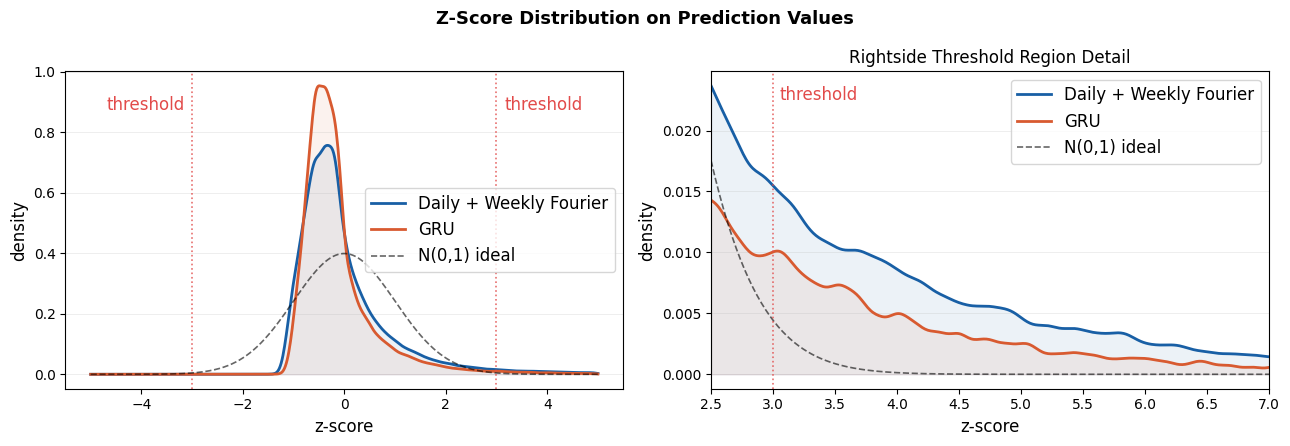


Saved → template/images/z_score_distribution.png


In [224]:
plot_zscore_distributions(
    zscore_csv_files=[
        'dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_anomalies_common_z_score_zscores.csv',
        "gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_anomalies_common_z_score_zscores.csv",
    ],
    model_names=["Daily + Weekly Fourier", "GRU"],
    result_csv_files=[
        "dynamic_trend_model/6_weeks_results_seasonal_uc_1000_seed_42_daily_clipped_tree_timeout_120_reworked_daily_weekly_fourier_anomalies_common_z_score.csv",
        "gru_predictor/6_weeks_results_gru_1000_seed_42_epochs_5_ws_5_sliding_window_anomalies_common_z_score.csv",
    ],
    only_converged=True,
    output_path="template/images/z_score_distribution.png",
)